In [15]:
#REGRESSION
#LINEAR REGRESSION
#Objective-Predict continuous Mobile Price using a single numerical feature (RAM).


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [16]:
df = pd.read_csv('Global_Mobile_Phone_Specifications_and_Prices_2026.csv',
                 low_memory=False)

In [17]:
#Convert the required columns into numbers

df['RAM'] = df['RAM'].str.extract('(\d+\.?\d*)')[0]
df['RAM'] = pd.to_numeric(df['RAM'], errors='coerce')

df['Battery_Capacity'] = df['Battery_Capacity'].str.extract('(\d+\.?\d*)')[0]
df['Battery_Capacity'] = pd.to_numeric(df['Battery_Capacity'], errors='coerce')

df['Display_Size'] = df['Display_Size'].str.extract('(\d+\.?\d*)')[0]
df['Display_Size'] = pd.to_numeric(df['Display_Size'], errors='coerce')

df['Price'] = df['Price'].str.replace('[^0-9.]', '', regex=True)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1757/238634997.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['RAM'] = df['RAM'].str.extract('(\d+\.?\d*)')[0]
/tmp/ipykernel_1757/238634997.py:4: SyntaxWarning: invalid escape sequence '\d'
  df['Battery_Capacity'] = df['Battery_Capacity'].str.extract('(\d+\.?\d*)')[0]
/tmp/ipykernel_1757/238634997.py:7: SyntaxWarning: invalid escape sequence '\d'
  df['Display_Size'] = df['Display_Size'].str.extract('(\d+\.?\d*)')[0]


In [18]:
df = df.dropna(subset=['RAM', 'Battery_Capacity', 'Display_Size', 'Price'])

In [19]:
X = df[['RAM']]
y = df['Price']

In [20]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [21]:
y_pred = model.predict(X)
score = r2_score(y, y_pred)

print(f"Simple Linear Regression R² Score: {score:.4f}\n")

Simple Linear Regression R² Score: 0.0000



In [22]:
new_ram = float(input("Enter RAM (GB): "))

new_data = pd.DataFrame([[new_ram]], columns=['RAM'])

Enter RAM (GB): 78


In [23]:
y_answer = model.predict(new_data)

print("Your predicted Mobile Price is:", y_answer[0])

Your predicted Mobile Price is: 2105886206.7448788


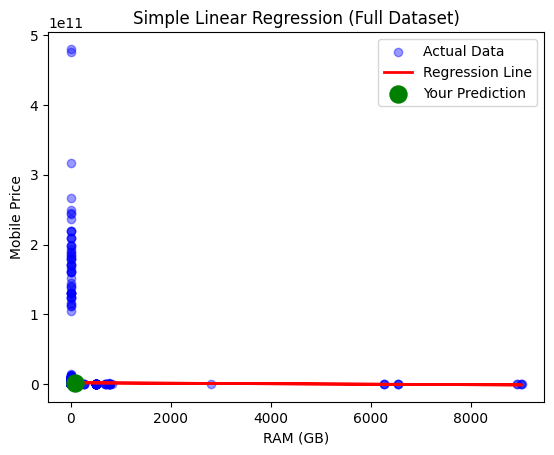

In [24]:
plt.scatter(X, y, color='blue', alpha=0.4, label='Actual Data')

plt.plot(X, y_pred, color='red', linewidth=2, label='Regression Line')

plt.scatter(new_ram, y_answer[0],
            color='green', s=150, zorder=5,
            label='Your Prediction')

plt.xlabel("RAM (GB)")
plt.ylabel("Mobile Price")
plt.title("Simple Linear Regression (Full Dataset)")
plt.legend()
plt.show()

In [25]:
#MULTIPLE LINEAR REGRESSION
#Objective - Predict continuous Mobile Price using multiple independent features (RAM, Battery Capacity, Display Size).

X = df[['RAM', 'Battery_Capacity', 'Display_Size']]
y = df['Price']

In [26]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [27]:
y_pred = model.predict(X)

score = r2_score(y, y_pred)

print(f"Multiple Linear Regression R² Score: {score:.4f}\n")

Multiple Linear Regression R² Score: 0.0001



In [28]:
new_ram = float(input("Enter RAM (GB): "))
new_battery = float(input("Enter Battery Capacity (mAh): "))
new_display = float(input("Enter Display Size (inch): "))

new_data = pd.DataFrame(
    [[new_ram, new_battery, new_display]],
    columns=['RAM', 'Battery_Capacity', 'Display_Size']
)

Enter RAM (GB): 66
Enter Battery Capacity (mAh): 78
Enter Display Size (inch): 765


In [29]:
y_answer = model.predict(new_data)

print("Your predicted Mobile Price is:", y_answer[0])

Your predicted Mobile Price is: 6028933079.645759


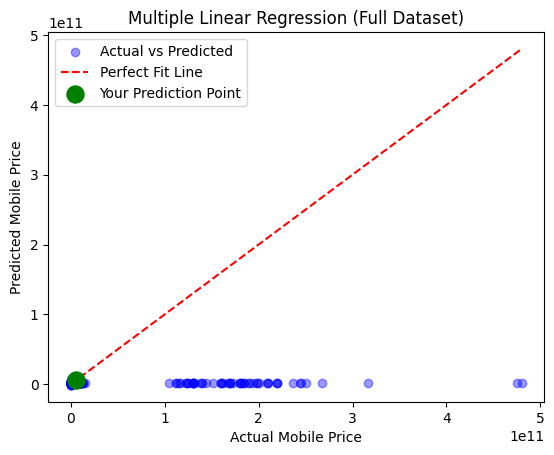

In [30]:
plt.scatter(y, y_pred,
            color='blue', alpha=0.4,
            label='Actual vs Predicted')

plt.plot([y.min(), y.max()],
         [y.min(), y.max()],
         'r--',
         label='Perfect Fit Line')

plt.scatter(y_answer[0], y_answer[0],
            color='green', s=150,
            zorder=5,
            label='Your Prediction Point')

plt.xlabel("Actual Mobile Price")
plt.ylabel("Predicted Mobile Price")
plt.title("Multiple Linear Regression (Full Dataset)")
plt.legend()
plt.show()

In [31]:
#LOGISTIC REGRESSION
#Objective - Classify whether a mobile is High Price (1) or Low/Medium Price (0) based on mobile features.

from sklearn.linear_model import LogisticRegression

df['High_Price'] = (
    df['Price'] > df['Price'].median()
).astype(int)




In [32]:
X = df[['RAM', 'Battery_Capacity', 'Display_Size']]
y = df['High_Price']

model = LogisticRegression()
model.fit(X, y)

LogisticRegression()

In [33]:
y_pred_all = model.predict(X)
y_prob_all = model.predict_proba(X)[:, 1]

In [34]:
print(f"Model R² Score: {r2_score(y, y_prob_all):.4f}\n")

Model R² Score: 0.0921



In [35]:
new_ram = float(input("Enter RAM (GB): "))
new_battery = float(input("Enter Battery Capacity (mAh): "))
new_display = float(input("Enter Display Size (inch): "))

new_data = pd.DataFrame(
    [[new_ram, new_battery, new_display]],
    columns=['RAM', 'Battery_Capacity', 'Display_Size']
)

Enter RAM (GB): 89
Enter Battery Capacity (mAh): 78
Enter Display Size (inch): 876


In [36]:
y_answer = model.predict(new_data)[0]

probabilities = model.predict_proba(new_data)[0]

print("\nPredicted Class (0 = Low/Med Price, 1 = High Price):",
      y_answer)

print(f"Probability of High Price: {probabilities[1] * 100:.2f}%")


Predicted Class (0 = Low/Med Price, 1 = High Price): 1
Probability of High Price: 56.47%


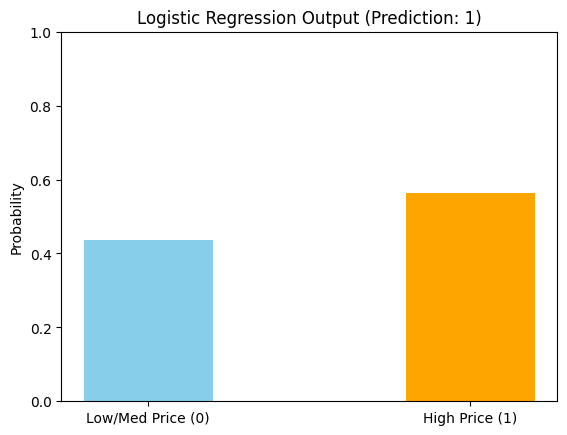

In [37]:
categories = ['Low/Med Price (0)', 'High Price (1)']

plt.bar(categories,
        probabilities,
        color=['skyblue', 'orange'],
        width=0.4)

plt.ylabel("Probability")
plt.ylim(0, 1)

plt.title(f"Logistic Regression Output (Prediction: {y_answer})")

plt.show()